


1️⃣ Setup & Data


In [1]:
!pip install -q tensorflow matplotlib

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

TARGET_DIGIT = 7
# Load MNIST
(x_train, y_train), _ = keras.datasets.mnist.load_data()

# Filter dataset to only the chosen digit
x_train = x_train[y_train == TARGET_DIGIT]

print(f"Training only on digit: {TARGET_DIGIT}")
print("Number of images:", x_train.shape[0])

# Normalize & expand dims
x_train = (x_train.astype("float32") - 127.5) / 127.5
x_train = np.expand_dims(x_train, axis=-1)

BUFFER_SIZE = len(x_train)
BATCH_SIZE = 128
LATENT_DIM = 100

train_dataset = (
    tf.data.Dataset.from_tensor_slices(x_train)
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE, drop_remainder=True)
)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training only on digit: 7
Number of images: 6265


2️⃣ Generator (DCGAN style – Conv2DTranspose)


In [2]:
def build_generator():
    model = keras.Sequential()
    model.add(layers.Input(shape=(LATENT_DIM,)))

    model.add(layers.Dense(7*7*128, use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())
    model.add(layers.Reshape((7, 7, 128)))

    model.add(layers.Conv2DTranspose(64, 5, strides=2, padding="same", use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(1, 5, strides=2, padding="same", use_bias=False, activation="tanh"))

    return model

generator = build_generator()
generator.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 6272)           │       627,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 6272)           │        25,088 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 1)      │         1,600 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 858,944 (3.28 MB)

 Trainable params: 846,272 (3.23 MB)

 Non-trainable params: 12,672 (49.50 KB)

3️⃣ Discriminator (Conv2D)


In [3]:
def build_discriminator():
    model = keras.Sequential()
    model.add(layers.Input(shape=(28, 28, 1)))

    model.add(layers.Conv2D(64, 5, strides=2, padding="same"))
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, 5, strides=2, padding="same"))
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1))

    return model

discriminator = build_discriminator()
discriminator.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

4️⃣ Losses & Optimizers


In [4]:
cross_entropy = keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real, fake):
    return cross_entropy(tf.ones_like(real), real) + \
           cross_entropy(tf.zeros_like(fake), fake)

def generator_loss(fake):
    return cross_entropy(tf.ones_like(fake), fake)

gen_opt  = keras.optimizers.Adam(1e-4)
disc_opt = keras.optimizers.Adam(1e-4)


5️⃣ Fixed seed & visualization function




In [5]:
SEED = tf.random.normal([16, LATENT_DIM])

def plot_generated(epoch, save=True):
    preds = generator(SEED, training=False)
    preds = (preds + 1) / 2.0  # back to [0,1]

    plt.figure(figsize=(4,4))
    for i in range(16):
        plt.subplot(4,4, i + 1)
        plt.imshow(preds[i, :, :, 0], cmap="gray")
        plt.axis("off")

    plt.suptitle(f"Generated '{TARGET_DIGIT}' at epoch {epoch}")
    plt.tight_layout()

    # 🔹 This line actually saves the image to disk
    if save:
        filename = f"digit_epoch{epoch}.png"
        plt.savefig(filename)
        print(f"Saved image grid as {filename}")

    plt.show()


6️⃣ One training step (using @tf.function for speed)


In [6]:
@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, LATENT_DIM])

    with tf.GradientTape() as g_tape, tf.GradientTape() as d_tape:
        generated = generator(noise, training=True)

        real_out = discriminator(images, training=True)
        fake_out = discriminator(generated, training=True)

        g_loss = generator_loss(fake_out)
        d_loss = discriminator_loss(real_out, fake_out)

    gradients_g = g_tape.gradient(g_loss, generator.trainable_variables)
    gradients_d = d_tape.gradient(d_loss, discriminator.trainable_variables)

    gen_opt.apply_gradients(zip(gradients_g, generator.trainable_variables))
    disc_opt.apply_gradients(zip(gradients_d, discriminator.trainable_variables))

    return g_loss, d_loss


7️⃣ Training loop (with visuals every few epochs)


Epoch 30/30  |  g_loss=0.9206 d_loss=1.0941
Saved image grid as digit_epoch30.png


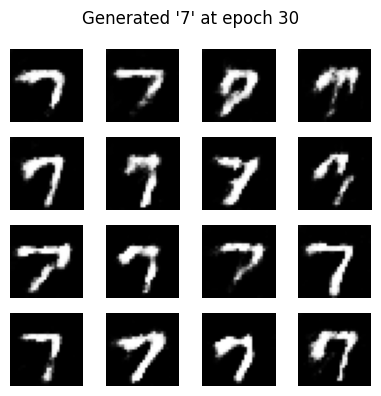

In [7]:
def train(dataset, epochs=30):
    for epoch in range(1, epochs+1):
        for image_batch in dataset:
            g_loss, d_loss = train_step(image_batch)

        clear_output(wait=True)
        print(f"Epoch {epoch}/{epochs}  |  g_loss={g_loss:.4f} d_loss={d_loss:.4f}")
        plot_generated(epoch)

train(train_dataset, epochs=30)


8️⃣ (Optional) Make a GIF of DCGAN progress


In [8]:
import imageio.v2 as imageio
import os

frames = []
for epoch in range(1, 101, 1):
    fname = f"digit_epoch{epoch}.png"
    if os.path.exists(fname):
        frames.append(imageio.imread(fname))

if frames:
    imageio.mimsave("dcgan_progress.gif", frames, duration=0.8)
    print("Saved GIF as dcgan_progress.gif")
else:
    print("No saved epoch images found.")


Saved GIF as dcgan_progress.gif
